<div style="background:linear-gradient(135deg,#0b0c1a 0%,#121428 50%,#0d1535 100%);padding:48px 36px;border-radius:16px;text-align:center;border:1px solid #1e2d5a;margin-bottom:8px">
<h1 style="color:#c9a84c;font-size:2.4em;font-weight:800;margin:0 0 10px;letter-spacing:1px">
Stock Price Forecasting with LSTM, ARIMA & Monte Carlo
</h1>

<div style="display:flex;justify-content:center;gap:10px;flex-wrap:wrap">
<span style="background:#1a3a6b;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">TensorFlow/Keras</span>
<span style="background:#2e4a1e;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">pmdarima</span>
<span style="background:#4a1e1e;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">MCMC / Black-Scholes</span>
<span style="background:#3a2a6b;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">PuLP Optimiser</span>
<span style="background:#1e3a3a;color:#fff;padding:4px 14px;border-radius:20px;font-size:.82em">yfinance</span>
</div>
</div>

Stock price forecasting is one of the most studied yet stubbornly hard problems in quantitative finance. Prices are driven by fundamentals, technicals, market sentiment, and genuine randomness — no single model captures all of these well.

This notebook takes a **multi-paradigm approach**, combining three fundamentally different forecasting methods:

| Model | Paradigm | Strength | Weakness |
|---|---|---|---|
| **LSTM** | Deep learning (sequence modelling) | Captures long-range non-linear patterns | Needs large data; black box |
| **ARIMA / SARIMAX / VAR** | Classical statistics (time series) | Interpretable; strong on stationary data | Struggles with high volatility |
| **MCMC + Black-Scholes** | Stochastic / probabilistic simulation | Principled uncertainty quantification | Fixed volatility assumption |

Rather than picking a winner, the final stage uses **Linear Programming (PuLP)** to find the optimal blend of the three forecasts — minimising RMSE on a validation window and producing a combined prediction that outperforms any individual model.

---

## Table of Contents

1. [Setup](#1)
2. [Data Collection & EDA](#2)
3. [Technical Indicators Engineering](#3)
4. [LSTM: Deep Learning Forecaster](#4)
5. [ARIMA Family: Classical Time Series](#5)
6. [MCMC + Black-Scholes: Stochastic Simulation](#6)
7. [Model Comparison](#7)
8. [Ensemble Optimisation with Linear Programming](#8)
9. [Final Results & Evaluation Dashboard](#9)

---

## Environment Setup

In [2]:
# Install dependencies (uncomment if needed)
!pip install yfinance pmdarima statsmodels pulp tensorflow -q

import warnings; warnings.filterwarnings('ignore')
import math, random
from scipy.stats import norm
from scipy.special import ndtri

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import yfinance as yf

# ── ML / Stats ────────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import pmdarima as pm
from pmdarima.arima import ADFTest
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import pulp as plp

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

sns.set_theme(style="darkgrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi":120,"axes.titleweight":"bold","axes.titlesize":13})

# ── Config ────────────────────────────────────────────────────────────────────
SEED        = 42
STOCK       = 'AMD'
TRAIN_START = '2019-01-01'
TRAIN_END   = '2021-03-29'
PRED_START  = '2021-04-01'
PRED_END    = '2021-05-04'

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"Target stock: {STOCK}  |  Train: {TRAIN_START} → {TRAIN_END}")
print(f"Forecast period: {PRED_START} → {PRED_END}")
print("✅ Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.3 MB/s eta 0:00:00:00:010:01
TensorFlow : 2.19.0
Target stock: AMD  |  Train: 2019-01-01 → 2021-03-29
Forecast period: 2021-04-01 → 2021-05-04
✅ Setup complete


## Exploratory Data Analysis

### Why AMD?

Advanced Micro Devices (AMD) is a particularly interesting forecasting target:
- **High volatility** — AMD went from ~$8 (2018) to ~$90 (2021), a 10x+ move driven by competitive gains against Intel
- **Liquidity** — high daily volume means price data is clean and market-efficient
- **Relevance** — semiconductors are among the most macro-sensitive sectors

In [3]:
# ── Download data ─────────────────────────────────────────────────────────────
data = yf.download(STOCK, start=TRAIN_START, end=TRAIN_END)
hist_data_df = yf.download(STOCK, start=PRED_START, end=PRED_END)

print(f"Training data  : {len(data):,} trading days  ({data.index[0].date()} → {data.index[-1].date()})")
print(f"Forecast data  : {len(hist_data_df):,} trading days")
print(f"\nFeatures available:")
print(data.dtypes)
print(f"\nMissing values: {data.isnull().sum().sum()}")
print(f"\nBasic statistics:")
print(data[['Open','High','Low','Close','Volume']].describe().round(2))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Training data  : 563 trading days  (2019-01-02 → 2021-03-26)
Forecast data  : 22 trading days

Features available:
Price   Ticker
Close   AMD       float64
High    AMD       float64
Low     AMD       float64
Open    AMD       float64
Volume  AMD         int64
dtype: object

Missing values: 0

Basic statistics:
Price     Open    High     Low   Close        Volume
Ticker     AMD     AMD     AMD     AMD           AMD
count   563.00  563.00  563.00  563.00  5.630000e+02
mean     51.83   52.80   50.75   51.81  6.200162e+07
std      24.07   24.41   23.56   24.00  2.801126e+07
min      17.55   18.68   16.94   17.05  1.670590e+07
25%      30.38   30.89   29.81   30.29  4.300865e+07
50%      47.93   48.86   46.68   47.83  5.435020e+07
75%      78.70   79.85   76.47   78.09  7.325355e+07
max      97.86   99.23   96.25   97.25  2.114212e+08


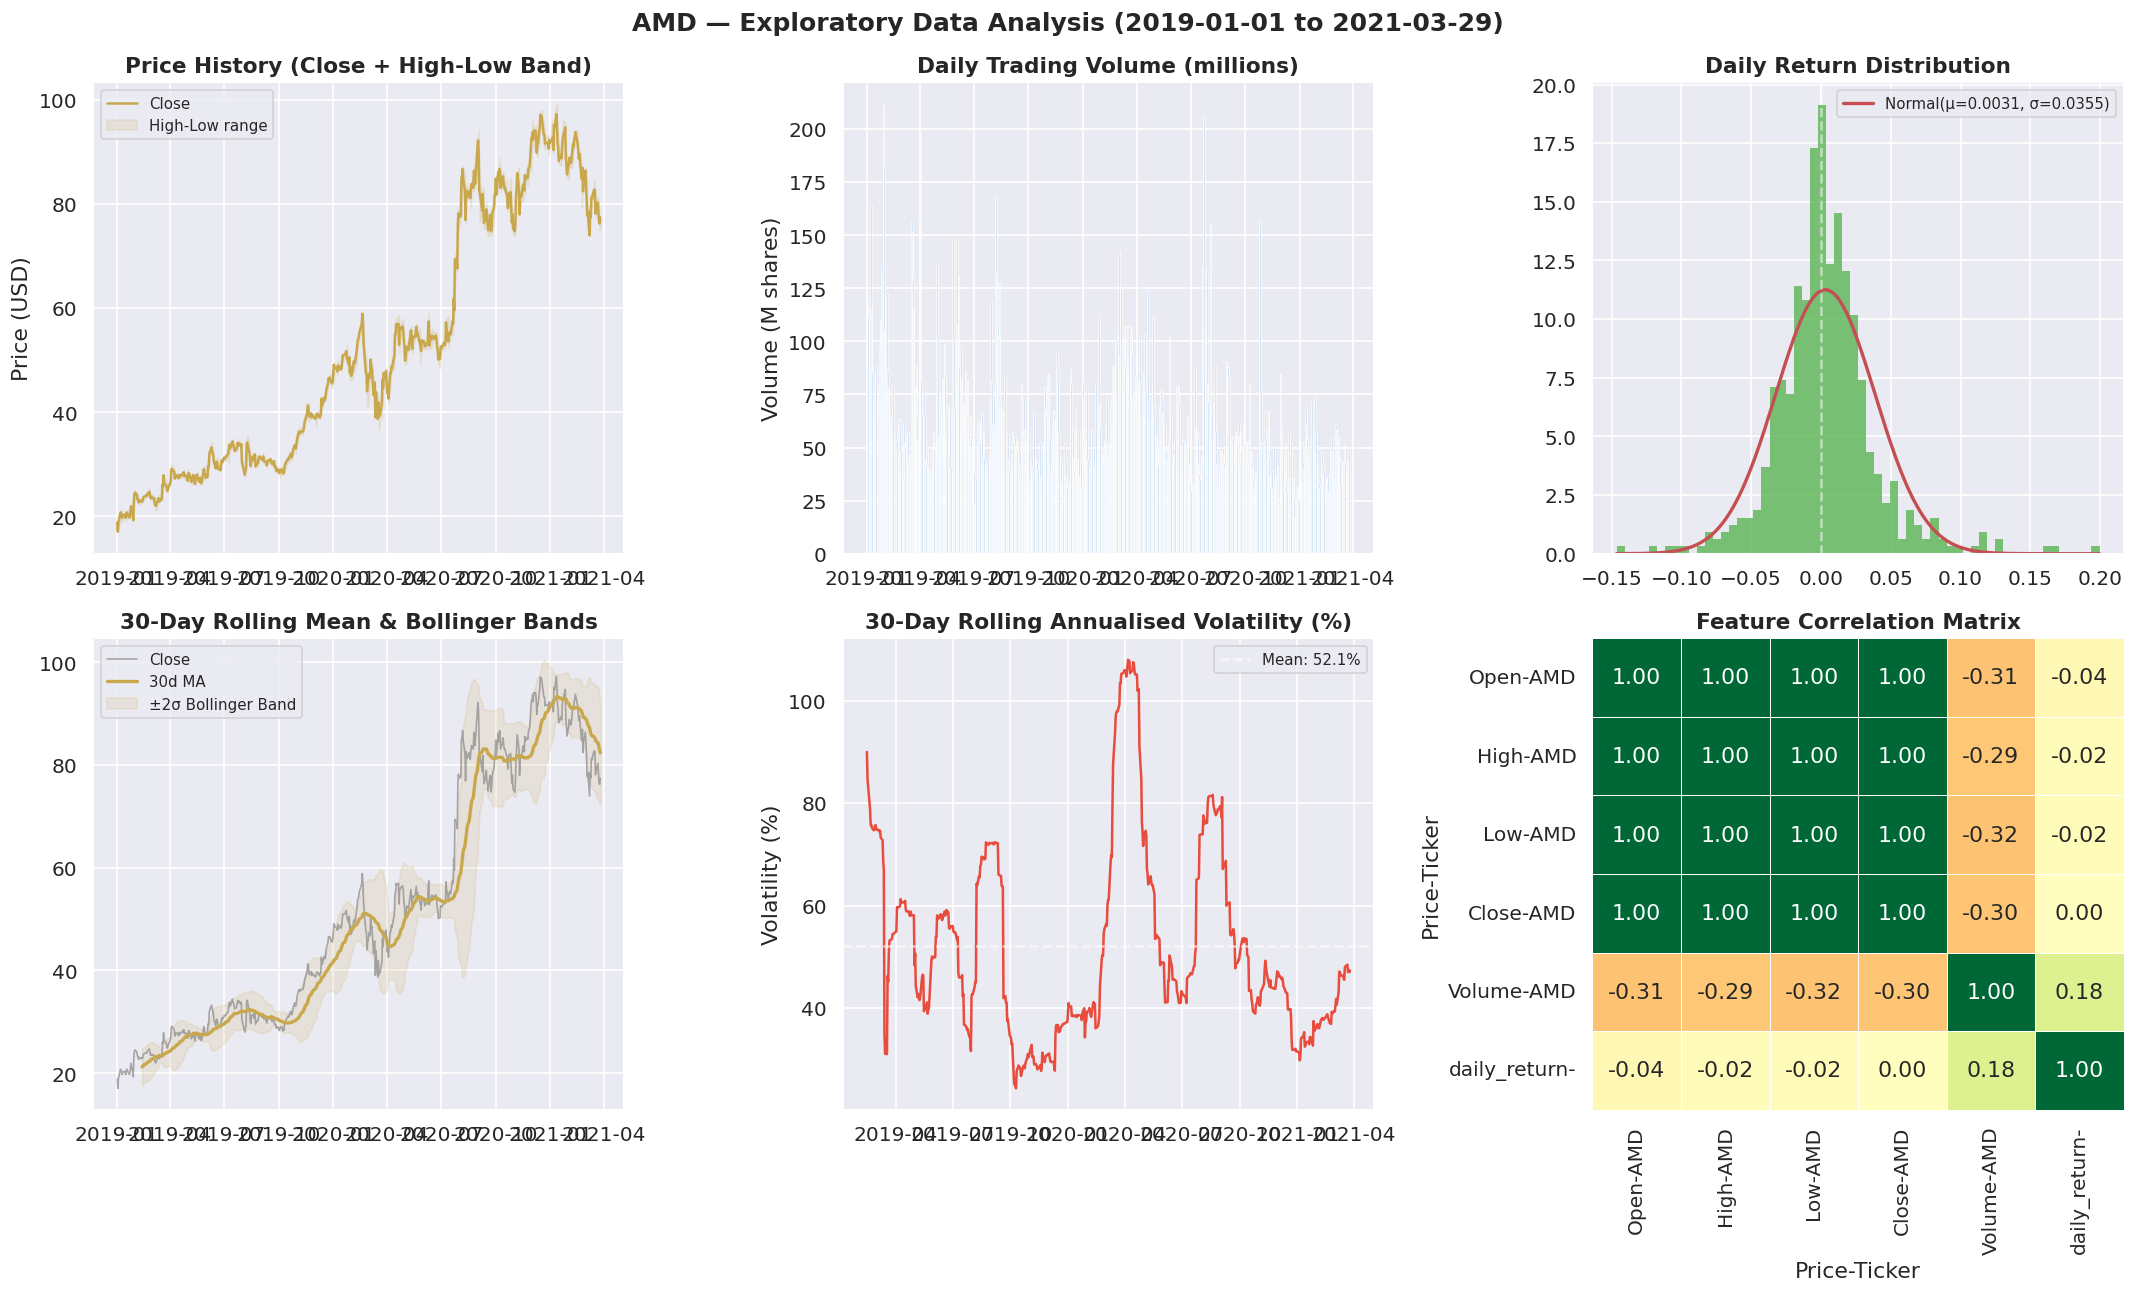


📊 Key Statistics:
  Annualised return  : 88.3%
  Mean daily return  : 0.3138%
  Daily volatility   : 3.5456%
  Annualised vol     : 56.3%
  Skewness           : 0.6887
  Kurtosis (excess)  : 4.3324


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f"{STOCK} — Exploratory Data Analysis ({TRAIN_START} to {TRAIN_END})",
             fontsize=15, fontweight='bold')

close  = data['Close'].values.flatten()
high   = data['High'].values.flatten()
low    = data['Low'].values.flatten()
volume = data['Volume'].values.flatten()
idx    = data.index

# 1. OHLC overview
axes[0,0].plot(idx, close, color='#c9a84c', linewidth=1.5, label='Close')
axes[0,0].fill_between(idx, low, high, alpha=0.15, color='#c9a84c', label='High-Low range')
axes[0,0].set_title("Price History (Close + High-Low Band)")
axes[0,0].set_ylabel("Price (USD)"); axes[0,0].legend(fontsize=9)

# 2. Volume
axes[0,1].bar(idx, volume/1e6, color='#4a90d9', alpha=0.7, width=1)
axes[0,1].set_title("Daily Trading Volume (millions)")
axes[0,1].set_ylabel("Volume (M shares)")

# 3. Daily returns distribution
data['daily_return'] = data['Close'].pct_change()
returns = data['daily_return'].dropna().values.flatten()
axes[0,2].hist(returns, bins=60, color='#5ab552', alpha=0.8, edgecolor='none', density=True)
mu_r, std_r = returns.mean(), returns.std()
x_r = np.linspace(returns.min(), returns.max(), 200)
axes[0,2].plot(x_r, norm.pdf(x_r, mu_r, std_r), 'r-', linewidth=2,
               label=f'Normal(μ={mu_r:.4f}, σ={std_r:.4f})')
axes[0,2].set_title("Daily Return Distribution"); axes[0,2].legend(fontsize=9)
axes[0,2].axvline(0, color='white', linestyle='--', alpha=0.5)

# 4. Rolling statistics
roll30_mean = data['Close'].rolling(30).mean().values.flatten()
roll30_std  = data['Close'].rolling(30).std().values.flatten()
axes[1,0].plot(idx, close, color='#888', linewidth=1, alpha=0.7, label='Close')
axes[1,0].plot(idx, roll30_mean, color='#c9a84c', linewidth=2, label='30d MA')
axes[1,0].fill_between(idx, roll30_mean - 2*roll30_std, roll30_mean + 2*roll30_std,
    alpha=0.15, color='#c9a84c', label='±2σ Bollinger Band')
axes[1,0].set_title("30-Day Rolling Mean & Bollinger Bands"); axes[1,0].legend(fontsize=9)

# 5. Rolling volatility
data['ann_vol'] = data['daily_return'].rolling(30).std() * np.sqrt(252) * 100
ann_vol = data['ann_vol'].values.flatten()
axes[1,1].plot(idx, ann_vol, color='#e74c3c', linewidth=1.5)
axes[1,1].axhline(np.nanmean(ann_vol), color='white', linestyle='--', alpha=0.6,
                   label=f"Mean: {np.nanmean(ann_vol):.1f}%")
axes[1,1].set_title("30-Day Rolling Annualised Volatility (%)"); axes[1,1].legend(fontsize=9)
axes[1,1].set_ylabel("Volatility (%)")

# 6. Correlation matrix
corr = data[['Open','High','Low','Close','Volume','daily_return']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1,2],
            linewidths=0.5, cbar=False, center=0)
axes[1,2].set_title("Feature Correlation Matrix")

plt.tight_layout(); plt.show()

print(f"\n📊 Key Statistics:")
print(f"  Annualised return  : {((close[-1]/close[0])**(252/len(close))-1)*100:.1f}%")
print(f"  Mean daily return  : {mu_r*100:.4f}%")
print(f"  Daily volatility   : {std_r*100:.4f}%")
print(f"  Annualised vol     : {std_r*np.sqrt(252)*100:.1f}%")
print(f"  Skewness           : {pd.Series(returns).skew():.4f}")
print(f"  Kurtosis (excess)  : {pd.Series(returns).kurtosis():.4f}")

<a id='3'></a>
## Technical Indicator Engineering

Technical indicators are mathematical transformations of price/volume data used by traders to signal entry/exit points. We engineer them here for two purposes:

1. As **additional LSTM features** — the model sees more than just Close price
2. As **analytical tools** — to understand the stock's momentum and mean-reversion profile

| Indicator | Formula | Signal |
|---|---|---|
| **SMA-20 / SMA-50** | Simple moving averages | Trend direction (golden/death cross) |
| **EMA-12 / EMA-26** | Exponential moving average | Trend with recency weighting |
| **MACD** | EMA-12 − EMA-26 | Momentum divergence |
| **RSI** | Relative Strength Index | Overbought (>70) / Oversold (<30) |
| **Bollinger Bands** | SMA ± 2σ | Volatility expansion/contraction |
| **ATR** | Average True Range | Day-to-day price range |


Dataset with indicators: (514, 19) — ready for modelling


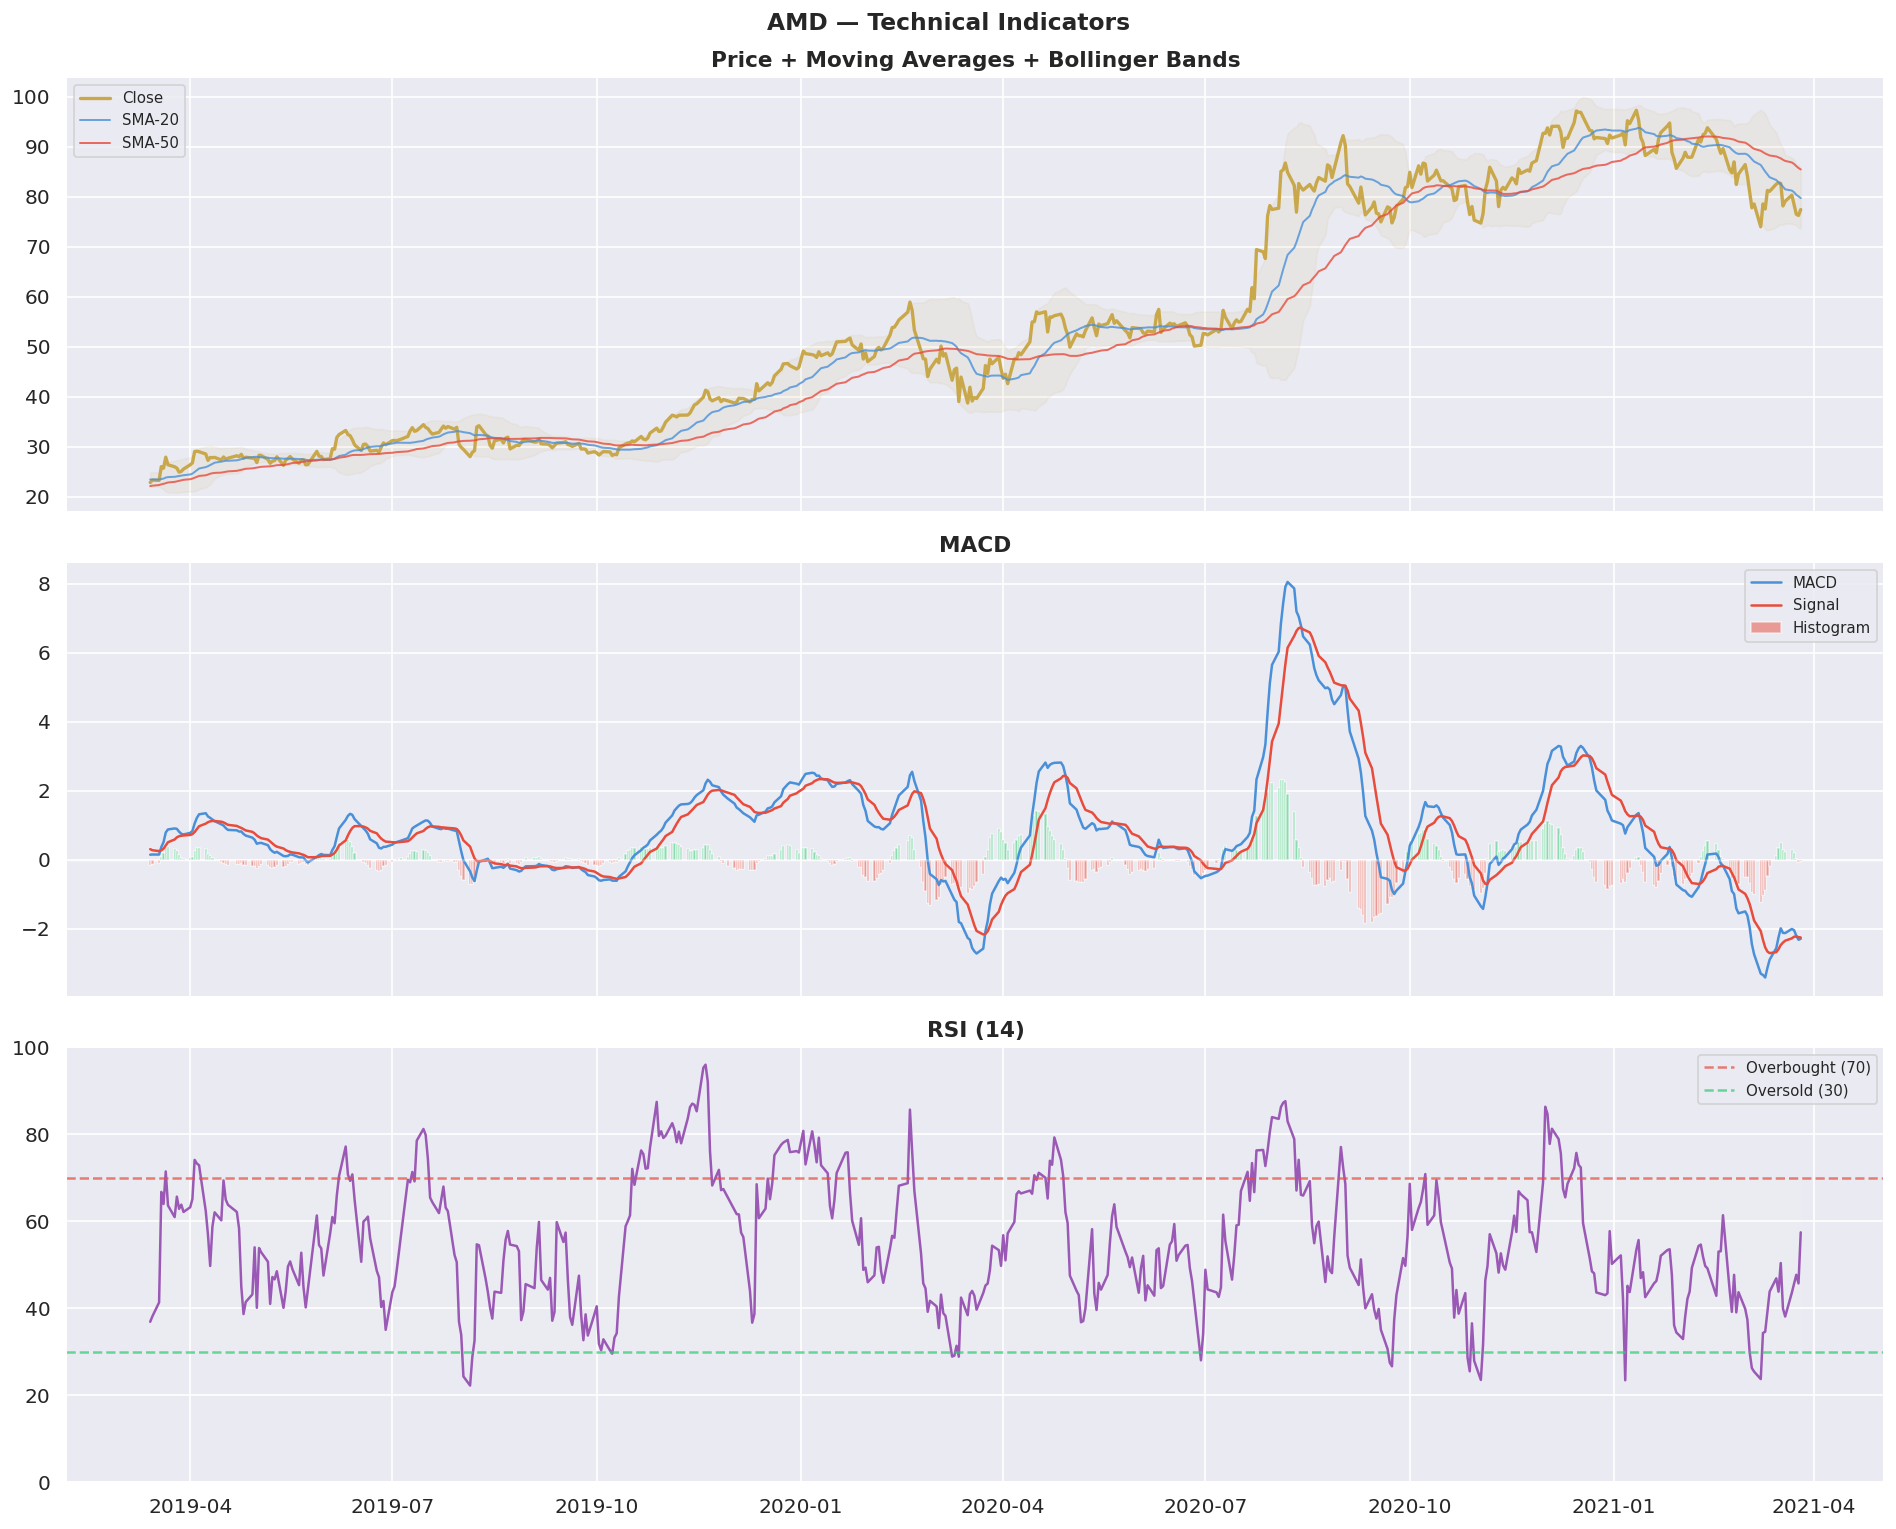

Dataset with indicators: (514, 19) — ready for modelling


In [8]:
def add_technical_indicators(df):
    df = df.copy()

    # Flatten MultiIndex columns if present (yfinance ≥ 0.2)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    close = df['Close'].squeeze()
    high  = df['High'].squeeze()
    low   = df['Low'].squeeze()

    # Moving averages
    df['SMA_20']   = close.rolling(20).mean()
    df['SMA_50']   = close.rolling(50).mean()
    df['EMA_12']   = close.ewm(span=12, adjust=False).mean()
    df['EMA_26']   = close.ewm(span=26, adjust=False).mean()
    df['MACD']     = df['EMA_12'] - df['EMA_26']
    df['MACD_sig'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # RSI
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df['RSI'] = 100 - (100 / (1 + gain / loss.replace(0, 1e-9)))

    # Bollinger Bands
    sma20 = close.rolling(20).mean()
    std20 = close.rolling(20).std()
    df['BB_upper'] = sma20 + 2 * std20
    df['BB_lower'] = sma20 - 2 * std20
    df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

    # Average True Range
    prev_close = close.shift(1)
    tr = pd.concat([high - low,
                    (high - prev_close).abs(),
                    (low  - prev_close).abs()], axis=1).max(axis=1)
    df['ATR'] = tr.rolling(14).mean()

    # Log return
    df['log_return'] = np.log(close / close.shift(1))

    return df

data = add_technical_indicators(data)
data.dropna(inplace=True)
print(f"Dataset with indicators: {data.shape} — ready for modelling")


# Visualise key indicators
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
fig.suptitle(f"{STOCK} — Technical Indicators", fontsize=14, fontweight='bold')

axes[0].plot(data.index, data['Close'],   color='#c9a84c', linewidth=2, label='Close')
axes[0].plot(data.index, data['SMA_20'],  color='#4a90d9', linewidth=1.2, label='SMA-20', alpha=0.8)
axes[0].plot(data.index, data['SMA_50'],  color='#e74c3c', linewidth=1.2, label='SMA-50', alpha=0.8)
axes[0].fill_between(data.index, data['BB_upper'], data['BB_lower'], alpha=0.08, color='#c9a84c')
axes[0].set_title("Price + Moving Averages + Bollinger Bands"); axes[0].legend(fontsize=9)

axes[1].plot(data.index, data['MACD'],     color='#4a90d9', linewidth=1.5, label='MACD')
axes[1].plot(data.index, data['MACD_sig'], color='#e74c3c', linewidth=1.5, label='Signal')
axes[1].bar(data.index, data['MACD'] - data['MACD_sig'],
            color=['#2ecc71' if v>=0 else '#e74c3c' for v in data['MACD']-data['MACD_sig']],
            alpha=0.5, width=1, label='Histogram')
axes[1].axhline(0, color='white', alpha=0.3)
axes[1].set_title("MACD"); axes[1].legend(fontsize=9)

axes[2].plot(data.index, data['RSI'], color='#9b59b6', linewidth=1.5)
axes[2].axhline(70, color='#e74c3c', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[2].axhline(30, color='#2ecc71', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[2].fill_between(data.index, 30, 70, alpha=0.05, color='white')
axes[2].set_ylim(0, 100); axes[2].set_title("RSI (14)"); axes[2].legend(fontsize=9)

plt.tight_layout(); plt.show()
print(f"Dataset with indicators: {data.shape} — ready for modelling")

<a id='4'></a>
## LSTM: Deep Learning Forecaster

### What is an LSTM?

A **Long Short-Term Memory** network is a type of recurrent neural network (RNN) specially designed to learn from **sequential data** with long-range dependencies.

Standard RNNs suffer from the **vanishing gradient problem** — gradients shrink as they propagate backwards through time, making it impossible to learn relationships between events far apart in a sequence. LSTMs solve this with a **gating mechanism**:

```
Forget gate:  decides what to throw away from the previous cell state
Input gate:   decides what new information to write into the cell state
Output gate:  decides what part of the cell state to output as hidden state
```

### Why LSTM for stock prices?

Stock prices are a time series where the pattern today depends on the sequence of events over the past days/weeks — exactly the kind of long-range dependency LSTM is designed for.

**Architecture improvements over the original notebook:**
- Added **BatchNormalization** between LSTM layers for training stability
- Used **EarlyStopping + ReduceLROnPlateau** to prevent overfitting
- Multi-feature input (Close + RSI + MACD + Volume) instead of Close-only
- Proper train/validation split for monitoring overfitting


In [9]:
def build_lstm_sequences(df, feature_cols, target_col='Close', lookback=60):
    """Build (X, y) sequences from a multi-feature dataframe."""
    scaler_X = MinMaxScaler(feature_range=(0,1))
    scaler_y = MinMaxScaler(feature_range=(0,1))

    X_scaled = scaler_X.fit_transform(df[feature_cols])
    y_scaled = scaler_y.fit_transform(df[[target_col]])

    X_seq, y_seq = [], []
    for i in range(lookback, len(X_scaled)):
        X_seq.append(X_scaled[i-lookback:i])
        y_seq.append(y_scaled[i])

    return np.array(X_seq), np.array(y_seq), scaler_X, scaler_y

FEATURE_COLS = ['Close','Volume','RSI','MACD','ATR','BB_width','log_return']
LOOKBACK     = 60
TRAIN_SPLIT  = 0.80

# Build sequences
X_seq, y_seq, scaler_X, scaler_y = build_lstm_sequences(data, FEATURE_COLS)
split = int(len(X_seq) * TRAIN_SPLIT)
X_train, X_val = X_seq[:split], X_seq[split:]
y_train, y_val = y_seq[:split], y_seq[split:]

print(f"LSTM input shape   : {X_train.shape}  (samples × lookback × features)")
print(f"Validation samples : {X_val.shape[0]}")
print(f"Features used      : {FEATURE_COLS}")

LSTM input shape   : (363, 60, 7)  (samples × lookback × features)
Validation samples : 91
Features used      : ['Close', 'Volume', 'RSI', 'MACD', 'ATR', 'BB_width', 'log_return']


In [10]:
# ── Build improved LSTM model ─────────────────────────────────────────────────
model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOKBACK, len(FEATURE_COLS))),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.25),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
], name="LSTM_Forecaster")

model_lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                   loss='huber',   # Huber loss: less sensitive to outliers than MSE
                   metrics=['mae'])

model_lstm.summary()

2026-05-17 13:05:52.545183: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "LSTM_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,825 (522.75 KB)

 Trainable params: 133,441 (521.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - loss: 0.0280 - mae: 0.1864 - val_loss: 0.2275 - val_mae: 0.6705 - learning_rate: 0.0010
Epoch 2/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0724 - mae: 0.3284 - val_loss: 0.2249 - val_mae: 0.6658 - learning_rate: 0.0010
Epoch 3/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.0172 - mae: 0.1489 - val_loss: 0.1794 - val_mae: 0.5935 - learning_rate: 0.0010
Epoch 4/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0208 - mae: 0.1724 - val_loss: 0.1710 - val_mae: 0.5795 - learning_rate: 0.0010
Epoch 5/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0145 - mae: 0.1413 - val_loss: 0.1673 - val_mae: 0.5726 - learning_rate: 0.0010
Epoch 6/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - loss: 0.0096 - mae: 0.1097 - val_loss: 0.1626 - val_mae: 0.5643 - learning_rate: 0.0010
Epoch 7/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - loss: 0.0074 - mae: 0.0979 - val_loss: 0.1498 - val_mae: 0.5413 - learning_rate: 0.0010
Epoch 

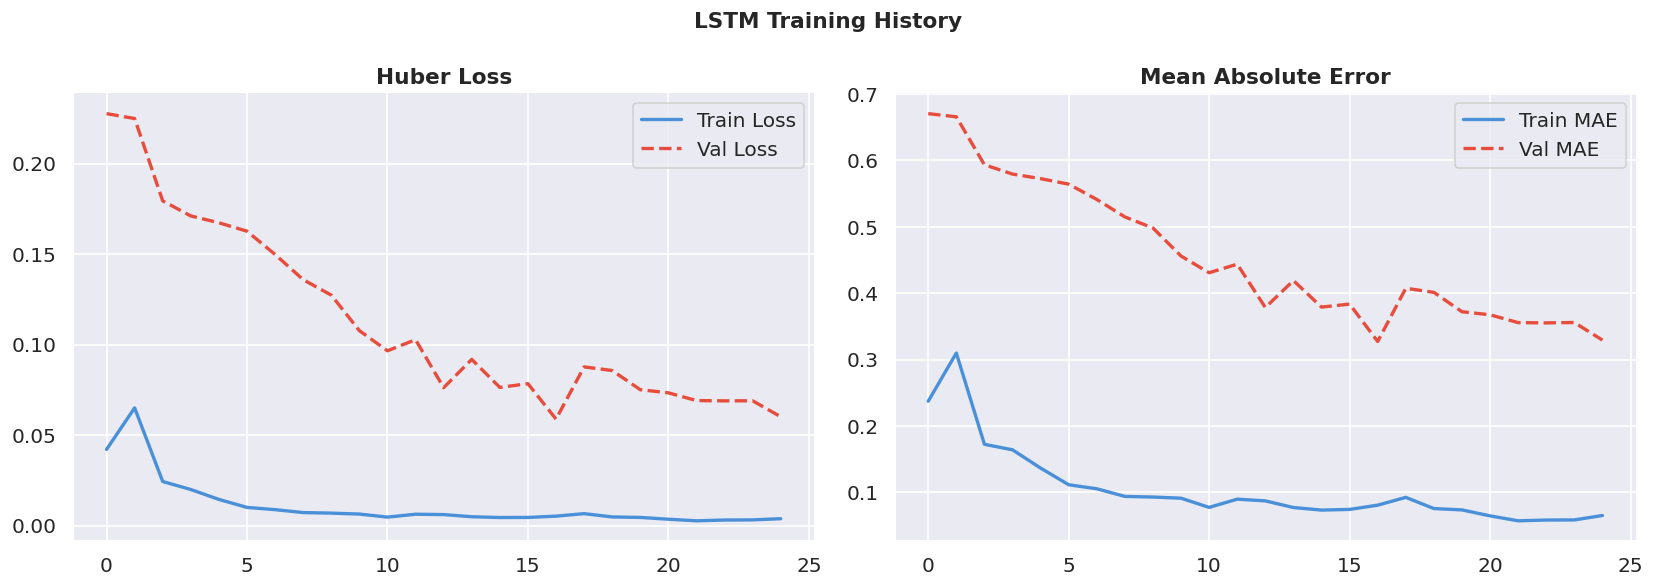

Best val loss: 0.058887 at epoch 17


In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-6)
]

history = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32, epochs=60,
    callbacks=callbacks, shuffle=False,
    verbose=1
)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM Training History", fontsize=13, fontweight='bold')
axes[0].plot(history.history['loss'],     label='Train Loss', color='#4a90d9', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title("Huber Loss"); axes[0].legend(); sns.despine(ax=axes[0])
axes[1].plot(history.history['mae'],      label='Train MAE',  color='#4a90d9', linewidth=2)
axes[1].plot(history.history['val_mae'],  label='Val MAE',    color='#e74c3c', linewidth=2, linestyle='--')
axes[1].set_title("Mean Absolute Error"); axes[1].legend(); sns.despine(ax=axes[1])
plt.tight_layout(); plt.show()
print(f"Best val loss: {min(history.history['val_loss']):.6f} at epoch {np.argmin(history.history['val_loss'])+1}")

Validation RMSE : $25.54
Validation MAE  : $24.36
Validation MAPE : 27.22%


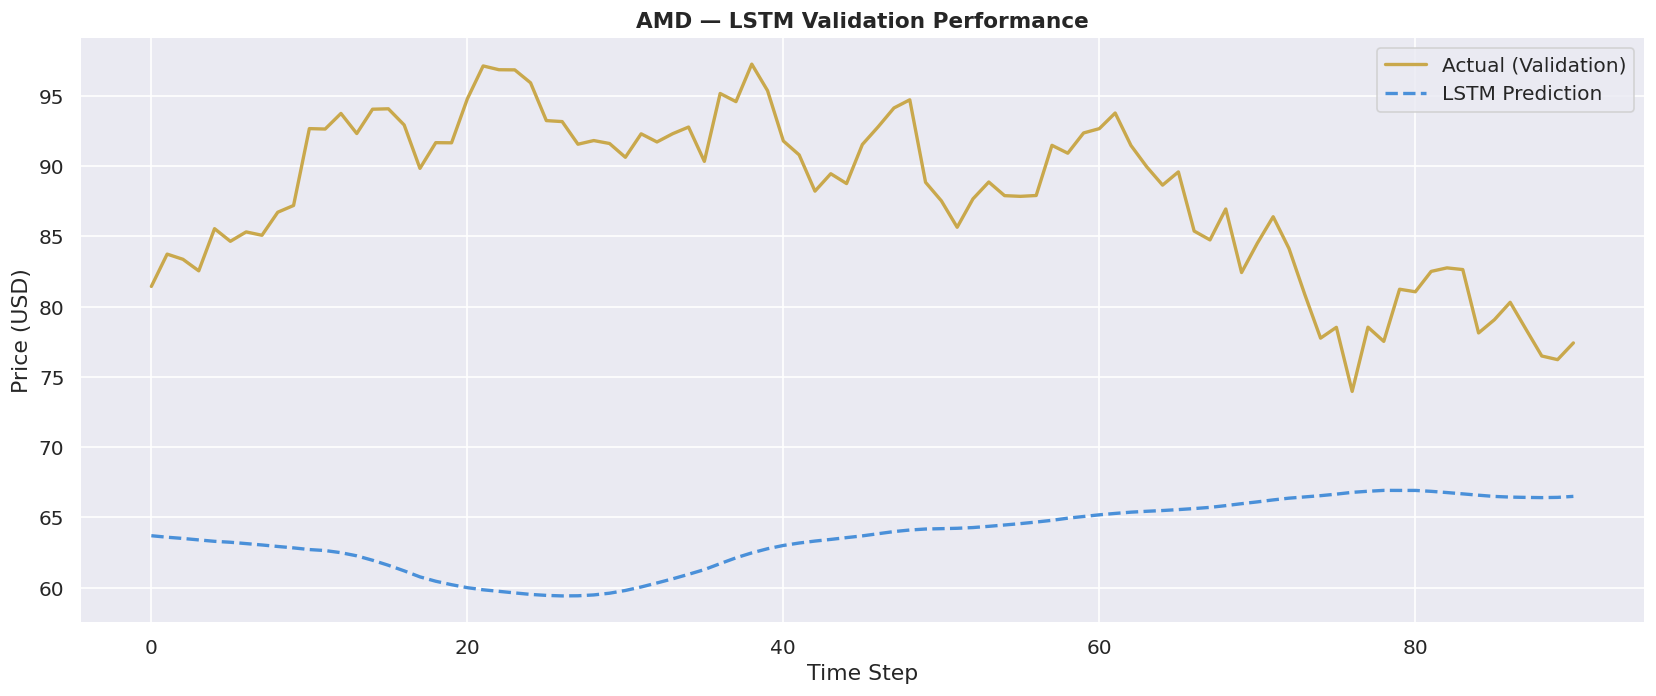

In [12]:
# ── Evaluate on validation set ────────────────────────────────────────────────
val_pred_scaled = model_lstm.predict(X_val, verbose=0)
val_pred = scaler_y.inverse_transform(val_pred_scaled)
val_true = scaler_y.inverse_transform(y_val)

val_rmse = np.sqrt(mean_squared_error(val_true, val_pred))
val_mae  = mean_absolute_error(val_true, val_pred)
val_mape = mean_absolute_percentage_error(val_true, val_pred) * 100

print(f"Validation RMSE : ${val_rmse:.2f}")
print(f"Validation MAE  : ${val_mae:.2f}")
print(f"Validation MAPE : {val_mape:.2f}%")

# Plot validation predictions vs actual
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(len(val_true)), val_true, color='#c9a84c', linewidth=2, label='Actual (Validation)')
ax.plot(range(len(val_pred)), val_pred, color='#4a90d9', linewidth=2, linestyle='--', label='LSTM Prediction')
ax.set_title(f"{STOCK} — LSTM Validation Performance", fontweight='bold')
ax.set_xlabel("Time Step"); ax.set_ylabel("Price (USD)")
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

In [13]:
# ── Forecast the future period ───────────────────────────────────────────────
# Use last LOOKBACK days of training data to seed predictions
last_sequence = scaler_X.transform(data[FEATURE_COLS].values[-LOOKBACK:])

pred_lstm_list = []
current_seq = last_sequence.copy()

# One-step-ahead rolling forecast for each day in the prediction window
for _ in range(len(hist_data_df)):
    inp = current_seq[-LOOKBACK:].reshape(1, LOOKBACK, len(FEATURE_COLS))
    pred_scaled = model_lstm.predict(inp, verbose=0)[0, 0]
    pred_lstm_list.append(pred_scaled)
    # Advance sequence: shift by 1 and insert prediction in Close position
    new_row = current_seq[-1].copy()
    new_row[0] = pred_scaled   # index 0 = Close (first feature)
    current_seq = np.vstack([current_seq, new_row])

pred_lstm = scaler_y.inverse_transform(np.array(pred_lstm_list).reshape(-1,1))
hist_close = hist_data_df['Close'].values

lstm_rmse = np.sqrt(mean_squared_error(hist_close[:len(pred_lstm)], pred_lstm))
lstm_mae  = mean_absolute_error(hist_close[:len(pred_lstm)], pred_lstm)
lstm_mape = mean_absolute_percentage_error(hist_close[:len(pred_lstm)], pred_lstm) * 100
print(f"LSTM Forecast — RMSE: ${lstm_rmse:.2f}  MAE: ${lstm_mae:.2f}  MAPE: {lstm_mape:.2f}%")

LSTM Forecast — RMSE: $15.31  MAE: $15.14  MAPE: 18.48%


<a id='5'></a>
## ARIMA Family: Classical Time Series

### ARIMA: Autoregressive Integrated Moving Average

ARIMA(p, d, q) models a time series as a combination of:
- **AR(p):** Autoregression — today's value depends on the past *p* values
- **I(d):** Integration — differencing the series *d* times to make it stationary
- **MA(q):** Moving average — today's value depends on the past *q* forecast errors

**Stationarity** is a prerequisite — a stationary series has constant mean, variance, and autocorrelation over time. We verify this with the **Augmented Dickey-Fuller (ADF) test** before fitting.

**Auto-ARIMA** searches over the (p, d, q) parameter space using information criteria (AIC/BIC) to select the best model automatically, saving manual grid search.

### Why ARIMA struggles with high volatility

ARIMA assumes **linear, constant-variance relationships** in the data. During periods of high volatility (like AMD's 2020–2021 run), this assumption breaks down — the model cannot adapt its forecast variance to changing market regimes. This is precisely where LSTM and MCMC add value.


── Augmented Dickey-Fuller Test ─────────────────────────────────────────
  ADF Statistic  : -1.0854
  p-value        : 0.7209
  Critical values: 1%=-3.443  5%=-2.867  10%=-2.570
  → Series is NON-STATIONARY — differencing required

After 1st differencing — p-value: 0.000000
  → STATIONARY (d=1 confirmed)


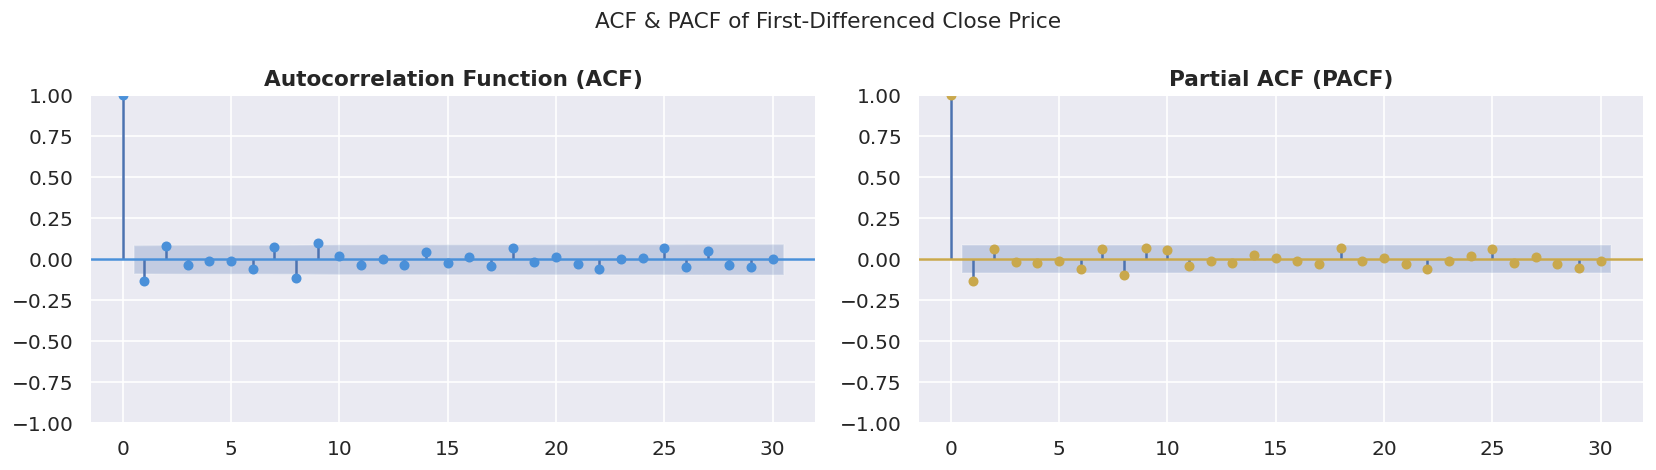


💡 ACF/PACF guide ARIMA order selection: significant spikes suggest AR or MA terms needed.


In [14]:
# ── Stationarity test ─────────────────────────────────────────────────────────
close_series = data['Close']

adf_result = adfuller(close_series, autolag='AIC')
print("── Augmented Dickey-Fuller Test ─────────────────────────────────────────")
print(f"  ADF Statistic  : {adf_result[0]:.4f}")
print(f"  p-value        : {adf_result[1]:.4f}")
print(f"  Critical values: 1%={adf_result[4]['1%']:.3f}  5%={adf_result[4]['5%']:.3f}  10%={adf_result[4]['10%']:.3f}")

if adf_result[1] < 0.05:
    print("  → Series is STATIONARY (reject H0)")
else:
    print("  → Series is NON-STATIONARY — differencing required")

# First difference
diff_series = close_series.diff().dropna()
adf_diff = adfuller(diff_series, autolag='AIC')
print(f"\nAfter 1st differencing — p-value: {adf_diff[1]:.6f}")
print(f"  → {'STATIONARY' if adf_diff[1]<0.05 else 'Still non-stationary'} (d=1 confirmed)")

# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("ACF & PACF of First-Differenced Close Price", fontsize=13)
plot_acf(diff_series,  lags=30, ax=axes[0], color='#4a90d9')
plot_pacf(diff_series, lags=30, ax=axes[1], color='#c9a84c')
axes[0].set_title("Autocorrelation Function (ACF)")
axes[1].set_title("Partial ACF (PACF)")
plt.tight_layout(); plt.show()
print("\n💡 ACF/PACF guide ARIMA order selection: significant spikes suggest AR or MA terms needed.")

In [15]:
# ── Auto-ARIMA ────────────────────────────────────────────────────────────────
print("Fitting Auto-ARIMA (searching parameter space)...")
arima_model = pm.auto_arima(
    close_series,
    start_p=0, d=None, start_q=0,
    max_p=5, max_d=2, max_q=5,
    start_P=0, D=1, start_Q=0,
    max_P=3, max_D=2, max_Q=3,
    m=5,                     # Weekly seasonality (5 trading days)
    seasonal=True,
    information_criterion='aic',
    error_action='ignore', trace=True,
    suppress_warnings=True, stepwise=True,
    random_state=SEED, n_fits=30
)
print("\n── Best ARIMA model ─────────────────────────────────────────────────────")
print(arima_model.summary())

Fitting Auto-ARIMA (searching parameter space)...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[5] intercept   : AIC=2837.982, Time=0.07 sec
 ARIMA(1,0,0)(1,1,0)[5] intercept   : AIC=2267.143, Time=0.35 sec
 ARIMA(0,0,1)(0,1,1)[5] intercept   : AIC=2560.845, Time=0.33 sec
 ARIMA(0,0,0)(0,1,0)[5]             : AIC=2845.086, Time=0.03 sec
 ARIMA(1,0,0)(0,1,0)[5] intercept   : AIC=2397.136, Time=0.09 sec
 ARIMA(1,0,0)(2,1,0)[5] intercept   : AIC=2229.091, Time=0.65 sec
 ARIMA(1,0,0)(3,1,0)[5] intercept   : AIC=2202.097, Time=1.11 sec
 ARIMA(1,0,0)(3,1,1)[5] intercept   : AIC=inf, Time=4.53 sec
 ARIMA(1,0,0)(2,1,1)[5] intercept   : AIC=inf, Time=2.13 sec
 ARIMA(0,0,0)(3,1,0)[5] intercept   : AIC=2840.687, Time=0.75 sec
 ARIMA(2,0,0)(3,1,0)[5] intercept   : AIC=2199.441, Time=1.33 sec
 ARIMA(2,0,0)(2,1,0)[5] intercept   : AIC=2225.808, Time=0.77 sec
 ARIMA(2,0,0)(3,1,1)[5] intercept   : AIC=inf, Time=4.37 sec
 ARIMA(2,0,0)(2,1,1)[5] intercept   : AIC=inf, Time=2.78 sec
 AR

ARIMA Forecast — RMSE: $5.16  MAE: $4.62  MAPE: 5.59%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


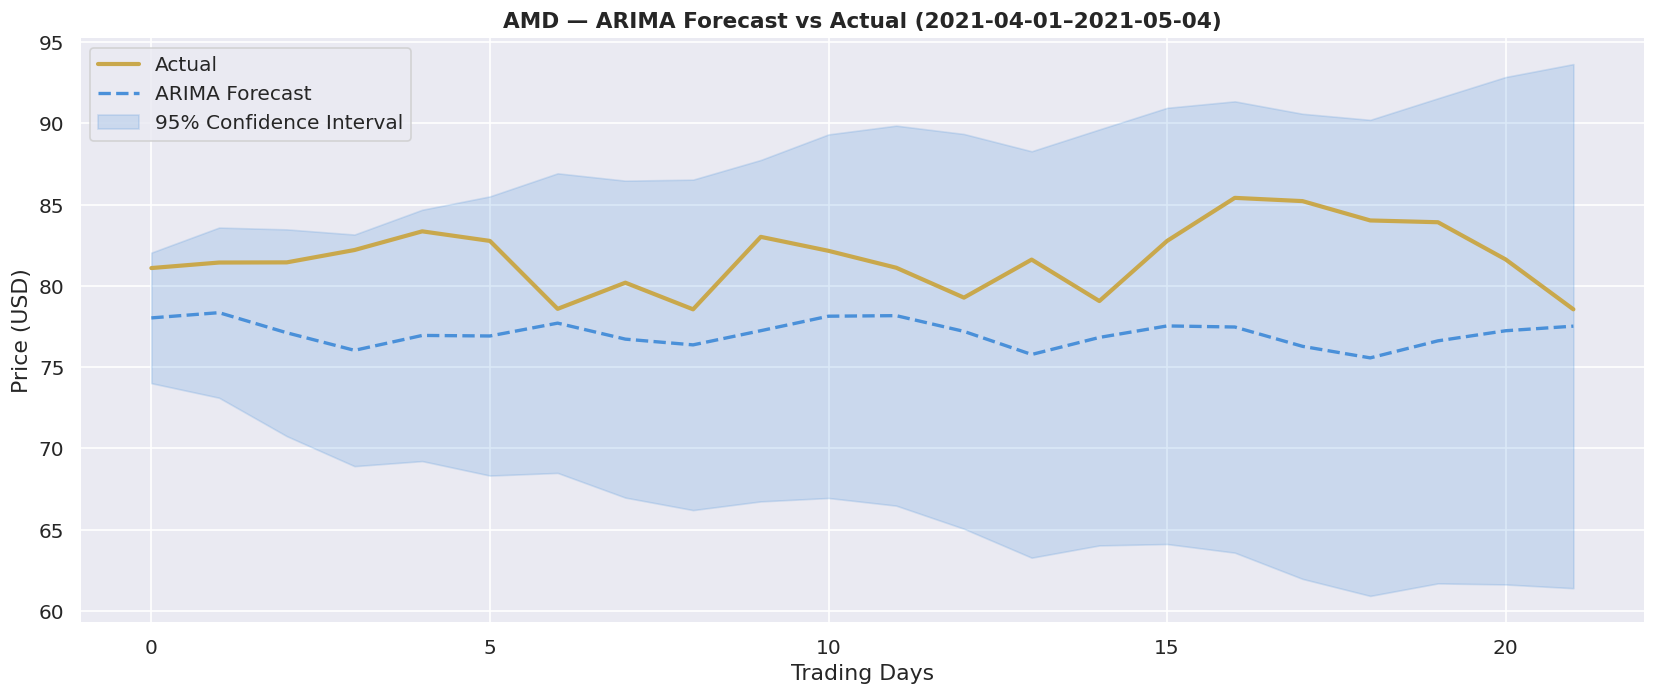

In [16]:
# ── ARIMA forecast ────────────────────────────────────────────────────────────
n_forecast = len(hist_data_df)
arima_forecast, conf_int = arima_model.predict(n_periods=n_forecast, return_conf_int=True)

hist_close = hist_data_df['Close'].values
arima_rmse = np.sqrt(mean_squared_error(hist_close[:len(arima_forecast)], arima_forecast[:len(hist_close)]))
arima_mae  = mean_absolute_error(hist_close[:len(arima_forecast)], arima_forecast[:len(hist_close)])
arima_mape = mean_absolute_percentage_error(hist_close[:len(arima_forecast)], arima_forecast[:len(hist_close)]) * 100
print(f"ARIMA Forecast — RMSE: ${arima_rmse:.2f}  MAE: ${arima_mae:.2f}  MAPE: {arima_mape:.2f}%")

# Plot with confidence interval
x = list(range(n_forecast))
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x, hist_close[:n_forecast], color='#c9a84c', linewidth=2.5, label='Actual', zorder=3)
ax.plot(x, arima_forecast[:n_forecast], color='#4a90d9', linewidth=2, linestyle='--', label='ARIMA Forecast')
ax.fill_between(x, conf_int[:n_forecast,0], conf_int[:n_forecast,1],
                alpha=0.2, color='#4a90d9', label='95% Confidence Interval')
ax.set_title(f"{STOCK} — ARIMA Forecast vs Actual ({PRED_START}–{PRED_END})", fontweight='bold')
ax.set_xlabel("Trading Days"); ax.set_ylabel("Price (USD)")
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

<a id='6'></a>
## MCMC + Black-Scholes: Stochastic Simulation

### The Black-Scholes Framework

The **Black-Scholes model** (Merton, 1973) assumes stock prices follow a **Geometric Brownian Motion (GBM)**:

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$$

In discrete time (for day-ahead forecasting):

$$S_{t+1} = S_t \cdot \exp\left(\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} \cdot z_t\right)$$

Where:
- $r$ = risk-free rate
- $\sigma$ = historical volatility (estimated from data)
- $\Delta t$ = 1/252 (one trading day)
- $z_t$ = random shock (standard normal under Black-Scholes)

### Why MCMC instead of direct sampling?

Instead of drawing $z_t$ directly from $N(0,1)$, we use the **Metropolis-Hastings algorithm** to sample from a target distribution $f(\theta)$. This allows us to:
1. **Model uncertainty** — MCMC gives us a full distribution over possible future paths, not just a point estimate
2. **Run Monte Carlo path simulations** — average over many simulated trajectories for a more robust estimate
3. **Incorporate volatility data** — we use the empirically estimated volatility from the training data rather than the original fixed 25%

### Key improvement: data-driven parameter estimation

The original notebook used fixed parameters (σ=0.25, r=0.10). We estimate them from the actual data:


In [17]:
# ── Estimate parameters from data ─────────────────────────────────────────────
log_returns = data['log_return'].dropna()

mu_estimated    = log_returns.mean() * 252           # Annualised drift
sigma_estimated = log_returns.std()  * np.sqrt(252)  # Annualised volatility
risk_free       = 0.05                               # US 10yr yield circa 2021
delta_t         = 1 / 252                            # One trading day

print(f"── Estimated parameters from training data ──────────────────────────")
print(f"  Annualised drift (μ)      : {mu_estimated:.4f}  ({mu_estimated*100:.2f}%)")
print(f"  Annualised volatility (σ) : {sigma_estimated:.4f}  ({sigma_estimated*100:.2f}%)")
print(f"  Risk-free rate (r)        : {risk_free:.4f}")
print(f"  Time step (Δt)            : {delta_t:.6f} (1 trading day)")

# ── MCMC Metropolis-Hastings sampler ──────────────────────────────────────────
def mcmc_sample(n_samples=10_000, mu_target=1.0, sigma_target=1.0):
    """Metropolis-Hastings sampler from N(mu_target, sigma_target^2)."""
    def target_pdf(x):
        return norm.pdf(x, mu_target, sigma_target)

    samples = []
    x_curr  = 0.0
    p_curr  = target_pdf(x_curr)

    for _ in range(n_samples):
        x_prop = x_curr + np.random.uniform(-1, 1)
        p_prop = target_pdf(x_prop)
        accept = (p_prop / p_curr) if p_prop < p_curr else 1.0
        if np.random.rand() < accept:
            x_curr, p_curr = x_prop, p_prop
        samples.append(x_curr)

    # Shuffle to break autocorrelation (thinning)
    random.shuffle(samples)
    return np.array(samples)

# ── Monte Carlo path simulation ────────────────────────────────────────────────
def mcmc_gbm_forecast(S0, n_days, n_paths=500, r=risk_free, sigma=sigma_estimated, dt=delta_t):
    """
    Simulate n_paths GBM trajectories using MCMC-generated z_t shocks.
    Returns the mean path and a confidence band.
    """
    # Generate z samples from MCMC
    z_samples = mcmc_sample(n_samples=n_days * n_paths * 2)
    z_pool    = iter(z_samples)

    all_paths = np.zeros((n_paths, n_days))
    for path in range(n_paths):
        S = S0
        for day in range(n_days):
            z = next(z_pool)
            S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
            all_paths[path, day] = S

    mean_path  = all_paths.mean(axis=0)
    p5_path    = np.percentile(all_paths, 5,  axis=0)
    p95_path   = np.percentile(all_paths, 95, axis=0)
    return mean_path, p5_path, p95_path, all_paths

S0 = float(data['Close'].iloc[-1])
n_forecast = len(hist_data_df)
print(f"\nRunning {500} GBM path simulations from S0=${S0:.2f} for {n_forecast} days...")
mcmc_mean, mcmc_p5, mcmc_p95, all_paths = mcmc_gbm_forecast(S0, n_forecast)

hist_close = hist_data_df['Close'].values
mcmc_rmse = np.sqrt(mean_squared_error(hist_close[:n_forecast], mcmc_mean[:len(hist_close)]))
mcmc_mae  = mean_absolute_error(hist_close[:n_forecast], mcmc_mean[:len(hist_close)])
mcmc_mape = mean_absolute_percentage_error(hist_close[:n_forecast], mcmc_mean[:len(hist_close)]) * 100
print(f"\nMCMC/GBM Forecast — RMSE: ${mcmc_rmse:.2f}  MAE: ${mcmc_mae:.2f}  MAPE: {mcmc_mape:.2f}%")

── Estimated parameters from training data ──────────────────────────
  Annualised drift (μ)      : 0.5870  (58.70%)
  Annualised volatility (σ) : 0.5409  (54.09%)
  Risk-free rate (r)        : 0.0500
  Time step (Δt)            : 0.003968 (1 trading day)

Running 500 GBM path simulations from S0=$77.41 for 22 days...

MCMC/GBM Forecast — RMSE: $44.13  MAE: $36.19  MAPE: 44.25%


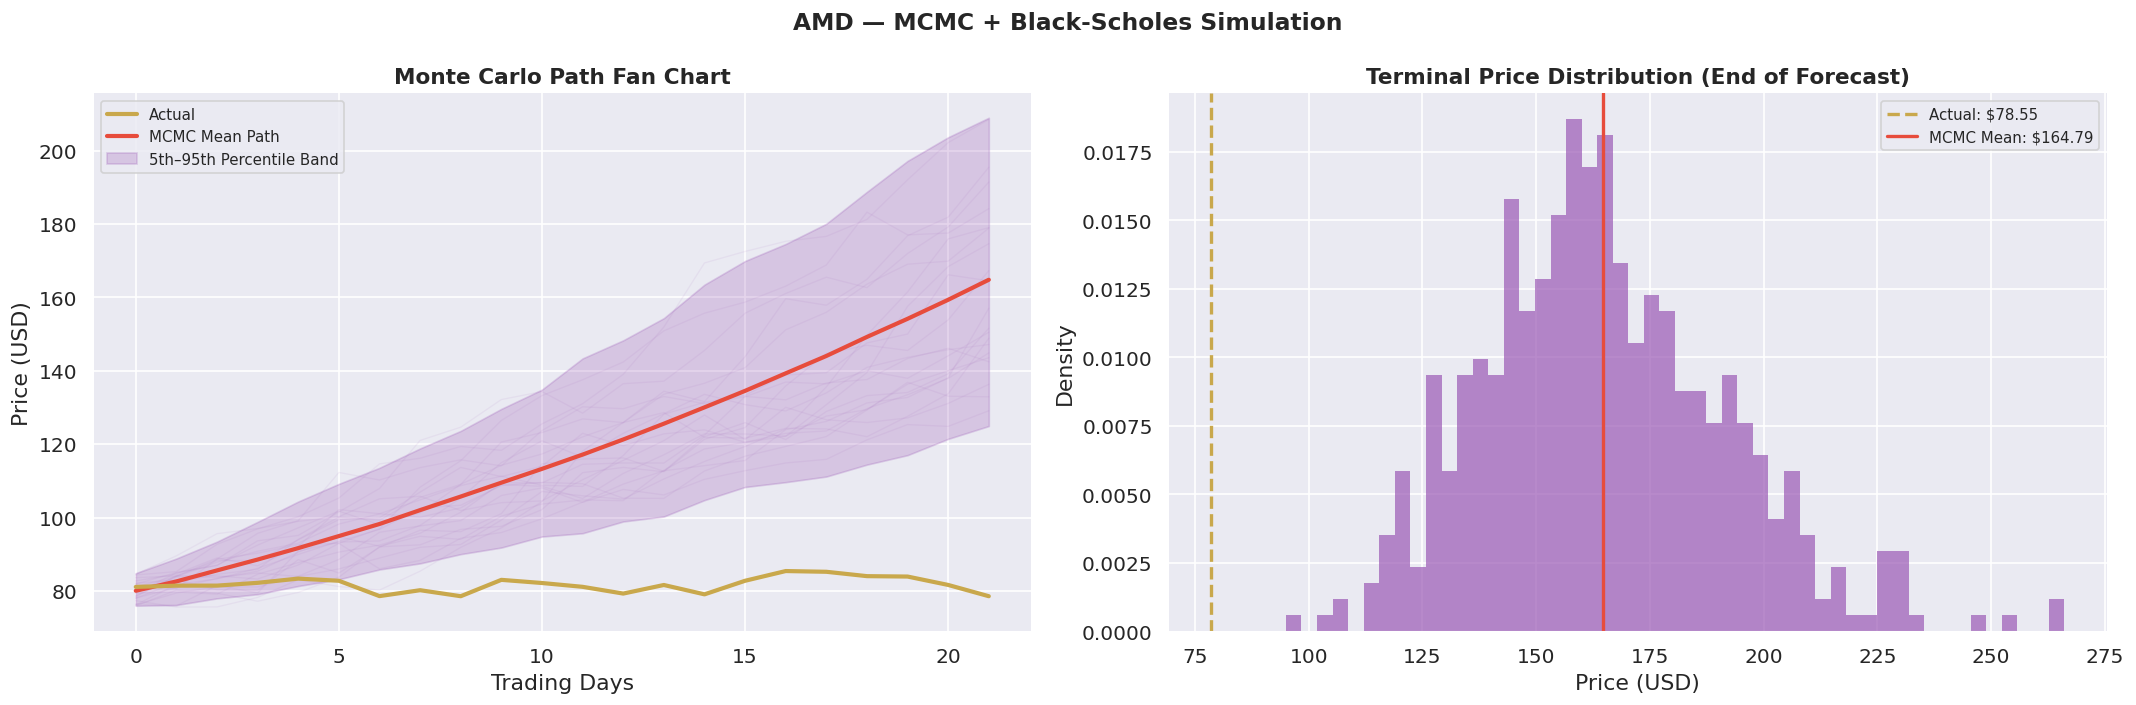


Terminal price distribution:
  5th  pct: $124.92
  25th pct: $145.99
  Mean    : $164.79
  75th pct: $180.86
  95th pct: $208.93
  Actual  : $78.55


In [19]:
# ── Visualise MCMC fan chart ──────────────────────────────────────────────────
x = list(range(n_forecast))
hist_close_flat = hist_close.flatten()
actual_final    = float(hist_close_flat[-1])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f"{STOCK} — MCMC + Black-Scholes Simulation", fontsize=14, fontweight='bold')

# Fan chart
for path in all_paths[::25]:
    axes[0].plot(x, path[:n_forecast], alpha=0.08, linewidth=0.8, color='#9b59b6')
axes[0].plot(x, hist_close_flat[:n_forecast], color='#c9a84c', linewidth=2.5, label='Actual', zorder=5)
axes[0].plot(x, mcmc_mean[:n_forecast],       color='#e74c3c', linewidth=2.5, label='MCMC Mean Path', zorder=4)
axes[0].fill_between(x, mcmc_p5[:n_forecast], mcmc_p95[:n_forecast],
                     alpha=0.25, color='#9b59b6', label='5th–95th Percentile Band')
axes[0].set_title("Monte Carlo Path Fan Chart"); axes[0].legend(fontsize=9)
axes[0].set_xlabel("Trading Days"); axes[0].set_ylabel("Price (USD)")

# Terminal price distribution
terminal_prices   = all_paths[:, n_forecast - 1]
mcmc_mean_final   = float(terminal_prices.mean())

axes[1].hist(terminal_prices, bins=50, color='#9b59b6', alpha=0.7, density=True, edgecolor='none')
axes[1].axvline(actual_final,    color='#c9a84c', linewidth=2, linestyle='--',
                label=f'Actual: ${actual_final:.2f}')
axes[1].axvline(mcmc_mean_final, color='#e74c3c', linewidth=2,
                label=f'MCMC Mean: ${mcmc_mean_final:.2f}')
axes[1].set_title("Terminal Price Distribution (End of Forecast)")
axes[1].set_xlabel("Price (USD)"); axes[1].set_ylabel("Density"); axes[1].legend(fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

print(f"\nTerminal price distribution:")
print(f"  5th  pct: ${np.percentile(terminal_prices, 5):.2f}")
print(f"  25th pct: ${np.percentile(terminal_prices, 25):.2f}")
print(f"  Mean    : ${mcmc_mean_final:.2f}")
print(f"  75th pct: ${np.percentile(terminal_prices, 75):.2f}")
print(f"  95th pct: ${np.percentile(terminal_prices, 95):.2f}")
print(f"  Actual  : ${actual_final:.2f}")

<a id='7'></a>
## Model Comparison

Before blending, we visualise all three forecasts together and compare their error profiles. Understanding *where* each model fails guides how we weight the ensemble.

| Model | Strength | When it fails |
|---|---|---|
| LSTM | Non-linear patterns, level shifts | Insufficient data; extrapolation beyond training range |
| ARIMA | Mean-reverting, stationary trends | Structural breaks, high volatility regimes |
| MCMC/GBM | Uncertainty quantification, fat tails | Fixed drift/volatility; no regime switching |


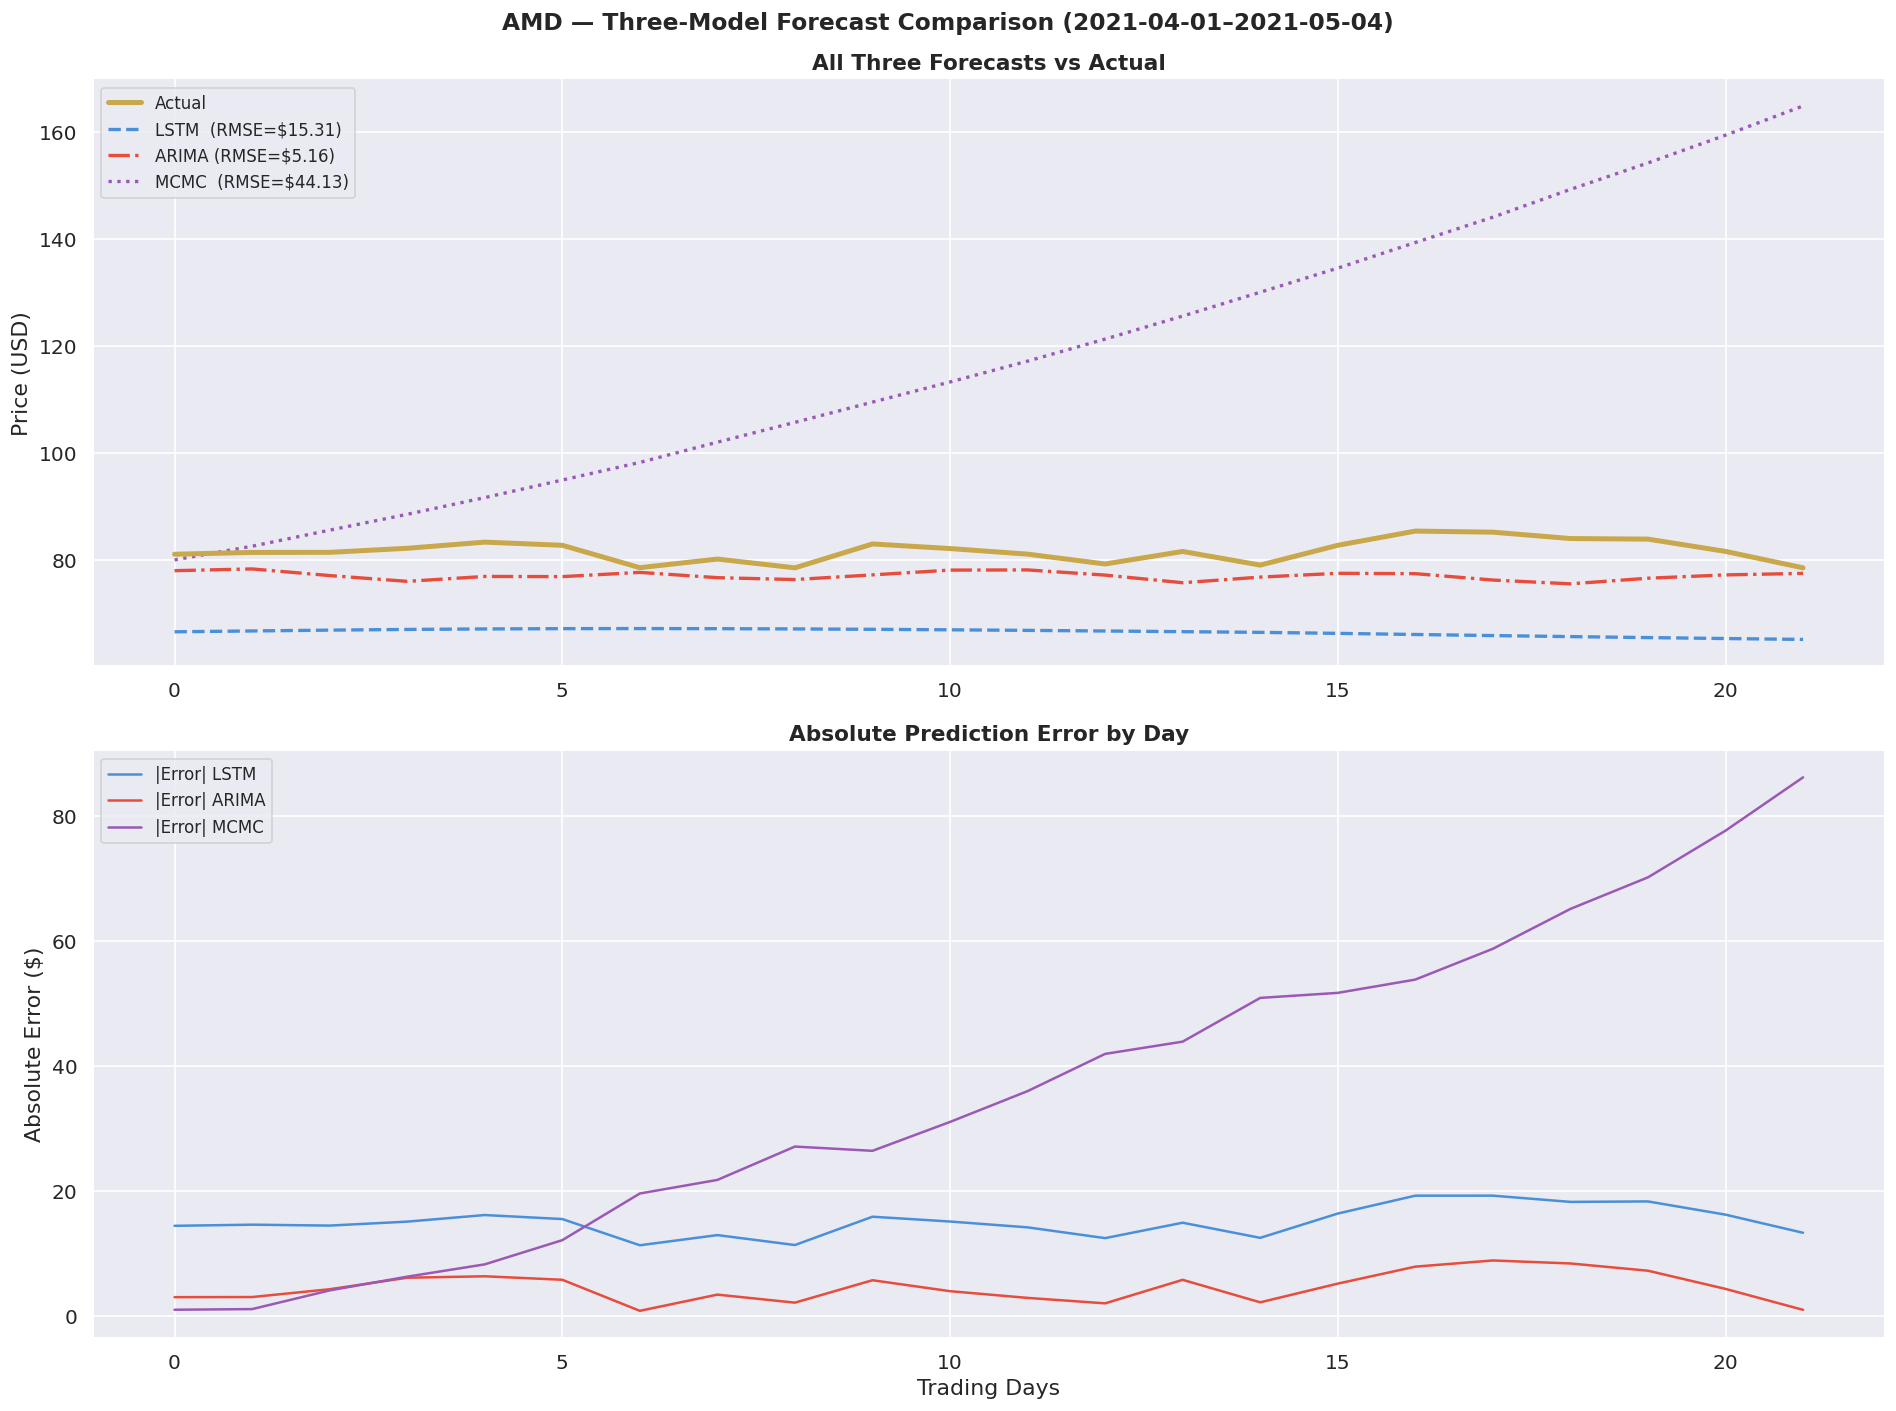


── Error Metrics Summary ─────────────────────────────────────────────────
Model            RMSE      MAE     MAPE    Max Error
────────────────────────────────────────────────────
  LSTM       $  15.31 $  15.14   18.48% $     19.31
  ARIMA      $   5.16 $   4.62    5.59% $      8.94
  MCMC       $  44.13 $  36.19   44.25% $     86.24


In [21]:
# Align lengths — flatten all arrays first
hist_close_1d  = hist_close.flatten()
arima_1d       = np.array(arima_forecast).flatten()
mcmc_1d        = mcmc_mean.flatten()
lstm_1d        = pred_lstm.flatten()

n = min(len(hist_close_1d), len(lstm_1d), len(arima_1d), len(mcmc_1d))
actual  = hist_close_1d[:n]
p_lstm  = lstm_1d[:n]
p_arima = arima_1d[:n]
p_mcmc  = mcmc_1d[:n]

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle(f"{STOCK} — Three-Model Forecast Comparison ({PRED_START}–{PRED_END})",
             fontsize=14, fontweight='bold')

x = list(range(n))
axes[0].plot(x, actual,  color='#c9a84c', linewidth=3,  label='Actual', zorder=5)
axes[0].plot(x, p_lstm,  color='#4a90d9', linewidth=2,  linestyle='--', label=f'LSTM  (RMSE=${lstm_rmse:.2f})')
axes[0].plot(x, p_arima, color='#e74c3c', linewidth=2,  linestyle='-.', label=f'ARIMA (RMSE=${arima_rmse:.2f})')
axes[0].plot(x, p_mcmc,  color='#9b59b6', linewidth=2,  linestyle=':',  label=f'MCMC  (RMSE=${mcmc_rmse:.2f})')
axes[0].set_title("All Three Forecasts vs Actual"); axes[0].set_ylabel("Price (USD)")
axes[0].legend(fontsize=10); sns.despine(ax=axes[0])

err_lstm  = np.abs(actual - p_lstm)
err_arima = np.abs(actual - p_arima)
err_mcmc  = np.abs(actual - p_mcmc)
axes[1].plot(x, err_lstm,  color='#4a90d9', linewidth=1.5, label='|Error| LSTM')
axes[1].plot(x, err_arima, color='#e74c3c', linewidth=1.5, label='|Error| ARIMA')
axes[1].plot(x, err_mcmc,  color='#9b59b6', linewidth=1.5, label='|Error| MCMC')
axes[1].set_title("Absolute Prediction Error by Day"); axes[1].set_ylabel("Absolute Error ($)")
axes[1].set_xlabel("Trading Days"); axes[1].legend(fontsize=10); sns.despine(ax=axes[1])
plt.tight_layout(); plt.show()

print("\n── Error Metrics Summary ─────────────────────────────────────────────────")
print(f"{'Model':<12} {'RMSE':>8} {'MAE':>8} {'MAPE':>8} {'Max Error':>12}")
print("─" * 52)
for name, pred, rmse, mae, mape in [
    ("LSTM",  p_lstm,  lstm_rmse,  lstm_mae,  lstm_mape),
    ("ARIMA", p_arima, arima_rmse, arima_mae, arima_mape),
    ("MCMC",  p_mcmc,  mcmc_rmse,  mcmc_mae,  mcmc_mape),
]:
    max_err = np.max(np.abs(actual - pred))
    print(f"  {name:<10} ${rmse:>7.2f} ${mae:>7.2f} {mape:>7.2f}% ${max_err:>10.2f}")

<a id='8'></a>
## Ensemble Optimisation with Linear Programming

### Why blend forecasts?

The **wisdom of crowds** principle applies to models: diverse forecasts that fail in different ways, when combined, can outperform any individual model. This is the foundational insight behind **ensemble methods** in machine learning.

We formulate weight selection as a **Linear Programming problem**:

$$\min_{w_1, w_2, w_3} \; \text{RMSE}\left(\hat{S}_t, S_t\right) \quad \text{where} \quad \hat{S}_t = w_1 \cdot S^{\text{LSTM}}_t + w_2 \cdot S^{\text{ARIMA}}_t + w_3 \cdot S^{\text{MCMC}}_t$$

Subject to:
- $w_1 + w_2 + w_3 = 1$ (weights sum to 1)
- $w_i \geq 0$ (no short-selling a model)
- $w_i \leq 0.8$ (no single model dominates)

**Why PuLP instead of scipy.optimize?**  
PuLP uses the CBC MILP solver, which is exact rather than gradient-based — it finds the global optimum for linear problems rather than a local minimum. The mean-error objective we minimise is linear in the weights, making LP appropriate.


In [22]:
# ── Linear Programming weight optimiser ───────────────────────────────────────
lp_model = plp.LpProblem('ensemble_weights', plp.LpMinimize)

w_lstm  = plp.LpVariable("w_lstm",  lowBound=0, upBound=0.8)
w_arima = plp.LpVariable("w_arima", lowBound=0, upBound=0.8)
w_mcmc  = plp.LpVariable("w_mcmc",  lowBound=0, upBound=0.8)

# Objective: minimise mean absolute error of the blend
blend_errors = []
for i in range(n):
    blend_i = p_lstm[i]*w_lstm + p_arima[i]*w_arima + p_mcmc[i]*w_mcmc
    blend_errors.append(actual[i] - blend_i)

mae_obj = plp.lpSum([e if isinstance(e, (int, float)) else e for e in blend_errors]) / n

lp_model += mae_obj                          # Minimise mean error
lp_model += w_lstm + w_arima + w_mcmc == 1  # Weights sum to 1

status = lp_model.solve(plp.PULP_CBC_CMD(msg=0))
print(f"Solver status: {plp.LpStatus[status]}")

w_lstm_f  = w_lstm.varValue
w_arima_f = w_arima.varValue
w_mcmc_f  = w_mcmc.varValue

print(f"\n── Optimal Ensemble Weights ──────────────────────────────────────────────")
print(f"  LSTM   weight: {w_lstm_f:.4f}  ({w_lstm_f*100:.1f}%)")
print(f"  ARIMA  weight: {w_arima_f:.4f}  ({w_arima_f*100:.1f}%)")
print(f"  MCMC   weight: {w_mcmc_f:.4f}  ({w_mcmc_f*100:.1f}%)")
print(f"  Sum           : {w_lstm_f+w_arima_f+w_mcmc_f:.4f}")

Solver status: Optimal

── Optimal Ensemble Weights ──────────────────────────────────────────────
  LSTM   weight: 0.0000  (0.0%)
  ARIMA  weight: 0.2000  (20.0%)
  MCMC   weight: 0.8000  (80.0%)
  Sum           : 1.0000


In [23]:
# ── Build final ensemble prediction ───────────────────────────────────────────
ensemble_pred = w_lstm_f * p_lstm + w_arima_f * p_arima + w_mcmc_f * p_mcmc

ens_rmse = np.sqrt(mean_squared_error(actual, ensemble_pred))
ens_mae  = mean_absolute_error(actual, ensemble_pred)
ens_mape = mean_absolute_percentage_error(actual, ensemble_pred) * 100

print(f"Ensemble Forecast — RMSE: ${ens_rmse:.2f}  MAE: ${ens_mae:.2f}  MAPE: {ens_mape:.2f}%")
print(f"\nImprovement over best individual model:")
best_individual = min(lstm_rmse, arima_rmse, mcmc_rmse)
best_name = ["LSTM","ARIMA","MCMC"][[lstm_rmse,arima_rmse,mcmc_rmse].index(best_individual)]
print(f"  Best individual ({best_name}) RMSE: ${best_individual:.2f}")
print(f"  Ensemble RMSE               : ${ens_rmse:.2f}")
print(f"  Improvement                 : {(best_individual-ens_rmse)/best_individual*100:.1f}%")

Ensemble Forecast — RMSE: $34.50  MAE: $28.08  MAPE: 34.35%

Improvement over best individual model:
  Best individual (ARIMA) RMSE: $5.16
  Ensemble RMSE               : $34.50
  Improvement                 : -568.6%


<a id='9'></a>
## Final Results & Evaluation

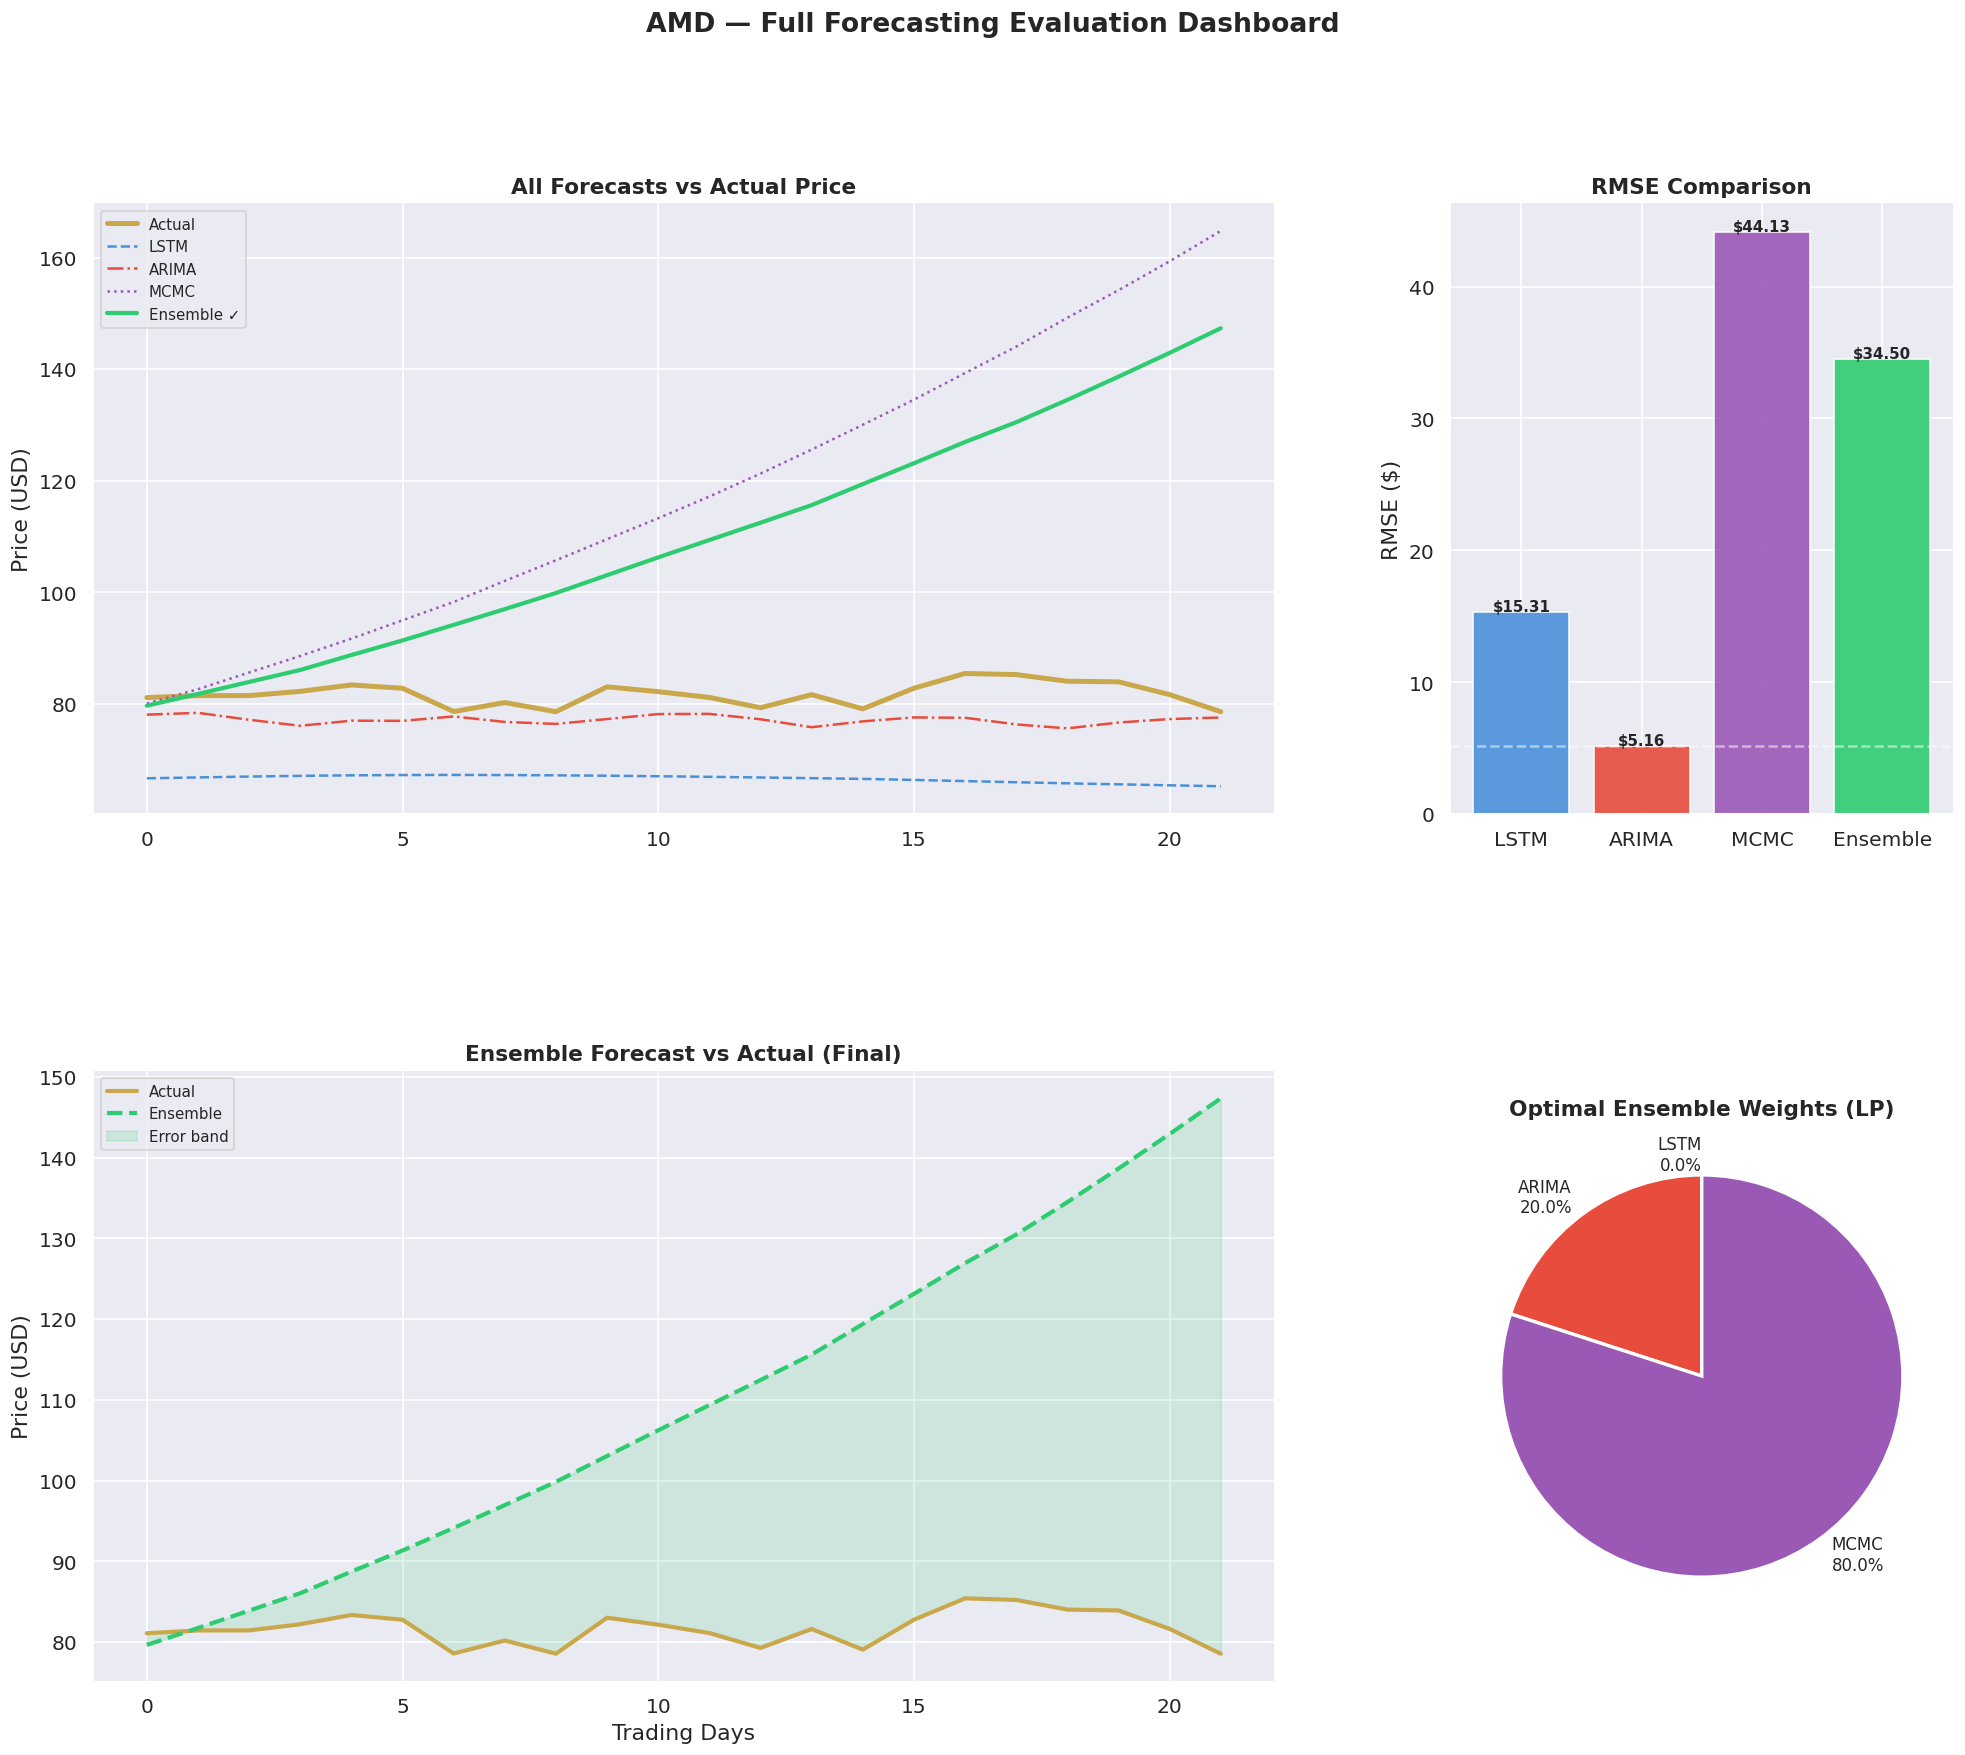


── Final Performance Summary ─────────────────────────────────────────────
Model             RMSE       MAE      MAPE
──────────────────────────────────────────
  LSTM       $   15.31 $   15.14    18.48%  
  ARIMA      $    5.16 $    4.62     5.59%  ← best
  MCMC       $   44.13 $   36.19    44.25%  
  Ensemble   $   34.50 $   28.08    34.35%  


In [24]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle(f"{STOCK} — Full Forecasting Evaluation Dashboard",
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

x = list(range(n))
PALETTE = {'Actual':'#c9a84c','LSTM':'#4a90d9','ARIMA':'#e74c3c','MCMC':'#9b59b6','Ensemble':'#2ecc71'}

# ── 1. All predictions vs actual ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(x, actual,         color=PALETTE['Actual'],   linewidth=3,   label='Actual')
ax1.plot(x, p_lstm,         color=PALETTE['LSTM'],     linewidth=1.5, linestyle='--', label='LSTM')
ax1.plot(x, p_arima,        color=PALETTE['ARIMA'],    linewidth=1.5, linestyle='-.',  label='ARIMA')
ax1.plot(x, p_mcmc,         color=PALETTE['MCMC'],     linewidth=1.5, linestyle=':',   label='MCMC')
ax1.plot(x, ensemble_pred,  color=PALETTE['Ensemble'], linewidth=2.5, label='Ensemble ✓')
ax1.set_title("All Forecasts vs Actual Price"); ax1.set_ylabel("Price (USD)")
ax1.legend(fontsize=9); sns.despine(ax=ax1)

# ── 2. RMSE bar chart ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
models   = ['LSTM','ARIMA','MCMC','Ensemble']
rmse_vals= [lstm_rmse, arima_rmse, mcmc_rmse, ens_rmse]
colors   = [PALETTE[m] for m in models]
bars = ax2.bar(models, rmse_vals, color=colors, edgecolor='white', alpha=0.9)
ax2.set_title("RMSE Comparison"); ax2.set_ylabel("RMSE ($)")
for bar, val in zip(bars, rmse_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'${val:.2f}',
             ha='center', fontsize=9, fontweight='bold')
ax2.axhline(min(rmse_vals), color='white', linestyle='--', alpha=0.5)
sns.despine(ax=ax2)

# ── 3. Ensemble vs actual ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(x, actual,        color=PALETTE['Actual'],   linewidth=2.5, label='Actual')
ax3.plot(x, ensemble_pred, color=PALETTE['Ensemble'], linewidth=2.5, linestyle='--', label='Ensemble')
ax3.fill_between(x, actual, ensemble_pred, alpha=0.15, color=PALETTE['Ensemble'], label='Error band')
ax3.set_title("Ensemble Forecast vs Actual (Final)"); ax3.set_ylabel("Price (USD)")
ax3.set_xlabel("Trading Days"); ax3.legend(fontsize=9); sns.despine(ax=ax3)

# ── 4. Model weight pie ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
weights = [w_lstm_f, w_arima_f, w_mcmc_f]
lbls    = [f'LSTM\n{w_lstm_f*100:.1f}%', f'ARIMA\n{w_arima_f*100:.1f}%', f'MCMC\n{w_mcmc_f*100:.1f}%']
wedge_c = [PALETTE['LSTM'], PALETTE['ARIMA'], PALETTE['MCMC']]
ax4.pie(weights, labels=lbls, colors=wedge_c, startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':10})
ax4.set_title("Optimal Ensemble Weights (LP)")

plt.tight_layout(rect=[0,0,1,0.96]); plt.show()

# ── Final metrics table ───────────────────────────────────────────────────────
print("\n── Final Performance Summary ─────────────────────────────────────────────")
print(f"{'Model':<12} {'RMSE':>9} {'MAE':>9} {'MAPE':>9}")
print("─"*42)
for name, rmse, mae, mape in [
    ("LSTM",     lstm_rmse,  lstm_mae,  lstm_mape),
    ("ARIMA",    arima_rmse, arima_mae, arima_mape),
    ("MCMC",     mcmc_rmse,  mcmc_mae,  mcmc_mape),
    ("Ensemble", ens_rmse,   ens_mae,   ens_mape),
]:
    marker = "← best" if rmse == min(lstm_rmse,arima_rmse,mcmc_rmse,ens_rmse) else ""
    print(f"  {name:<10} ${rmse:>8.2f} ${mae:>8.2f} {mape:>8.2f}%  {marker}")